2026-08-12 15:13:45.206 | INFO     | __main__:audit_node:42 - 任务阶段已经全部执行完毕,诗已生成,笑话已生成


{
    'topic': '猫咪',
    'poem': 
'好的，这是一首关于猫咪的诗：\n\n**猫之歌**\n\n一身绒毛软如云，步履轻盈过厅堂。\n琥珀双瞳映月光，深邃神秘自思量。\n
\n窗边暖阳洒金光，它便蜷卧入梦乡。\n忽而伸展四肢长，柔软身段惹人赏。\n\n小爪轻拨线团晃，眼神锐利似刀光。\n喉间咕噜
轻声响，是它心满意足唱。\n\n不求常伴人身旁，自有高傲与疏狂。\n偶尔蹭腿轻声唤，一声喵呜暖心房。\n\n它是家中一幅画，
灵动跳跃惹人夸。\n亦是夜里守望者，温暖我心伴韶华。',
    'joke': '好的，来一个关于猫咪的笑话：\n\n**问：** 为什么猫咪总是抱怨家里没吃的？\n\n**答：** 
因为在它们看来，只要碗里还有一点点空隙，就说明你不够爱它，或者你家已经破产了！'
}

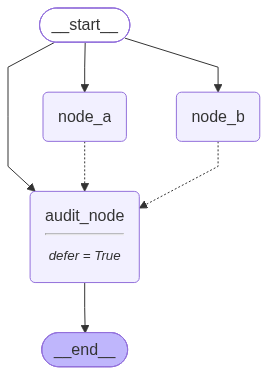

---
config:
  flowchart:
    curve: linear
---
graph TD;
	__start__([<p>__start__</p>]):::first
	node_a(node_a)
	node_b(node_b)
	audit_node(audit_node<hr/><small><em>defer = True</em></small>)
	__end__([<p>__end__</p>]):::last
	__start__ --> audit_node;
	__start__ --> node_a;
	__start__ --> node_b;
	node_a -.-> audit_node;
	node_b -.-> audit_node;
	audit_node --> __end__;
	classDef default fill:#f2f0ff,line-height:1.2
	classDef first fill-opacity:0
	classDef last fill:#bfb6fc



In [2]:
from typing import TypedDict,Literal
from loguru import logger
from langgraph.graph import StateGraph, START, END
from langchain.chat_models import init_chat_model
from rich import print as rprint
import os

from dotenv import load_dotenv
load_dotenv(override=True)

GEMINI_API_KEY=os.getenv("GEMINI_API_KEY")
GEMINI_BASE_URL=os.getenv("GEMINI_BASE_URL")

model = init_chat_model(
  model="gemini-2.5-flash",
  model_provider="google_genai",
  api_key=GEMINI_API_KEY,
  transport="rest"  # 强制使用 REST 协议
)

#1. 定义状态
class OverAllState(TypedDict):
    topic: str
    poem: str
    joke: str
    content_type: str

#2. 定义节点
def node_a(state: OverAllState) -> OverAllState:
    poem = model.invoke([f"写一首关于{state['topic']}主题的诗"]).content
    return {
        "poem": poem
    }

def node_b(state: OverAllState) -> OverAllState:
    joke = model.invoke([f"写一个关于{state['topic']}主题的笑话"]).content
    return {
        "joke": joke
    }

def audit_node(state: OverAllState) -> OverAllState:
    logger.info(f"任务阶段已经全部执行完毕,诗{'已生成' if state['poem'] else '未生成'},笑话{'已生成' if state['joke'] else '未生成'}")



#3. 构建图
builder = StateGraph(state_schema=OverAllState)
builder.add_node("node_a",node_a)
builder.add_node("node_b",node_b)
builder.add_node("audit_node",audit_node,defer=True)

builder.add_edge(START,"node_a")
builder.add_edge(START,"node_b")
builder.add_edge(START,"audit_node")
builder.add_edge("node_a",END)
builder.add_edge("node_b",END)
builder.add_edge("audit_node",END)

graph = builder.compile()
res = graph.invoke({"topic": "猫咪"})
rprint(res)


from IPython.display import display
display(graph)

raw_mermaid = graph.get_graph().draw_mermaid()
print(raw_mermaid)